In [20]:
import pandas as pd
import os
os.makedirs("images", exist_ok=True)

In [2]:
df = pd.read_csv(r"C:\Users\Rayan\Desktop\Data Analysis\5- Portfolio\ciclo2.projects\python-airbnb-market-analysis\Data\listings.csv")

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,13188,Garden level studio in ideal loc.,51466,Emma,NaN,Riley Park,49.247730,-123.105090,Entire home/apt,136.0,2,381,2025-09-16,1.99,1,170,41,Municipal registration number: 25-156058<br />...
1,13358,Downtown Boutique Suite,52116,Lynn,NaN,Downtown,49.281174,-123.125931,Entire home/apt,188.0,2,584,2025-10-20,3.11,1,178,36,Municipal registration number: 25-157257<br />...
2,16611,"1 block to skytrain station, shops,restaurant,...",58512,Q,NaN,Grandview-Woodland,49.263390,-123.071450,Entire home/apt,NaN,365,3,2018-02-16,0.03,5,89,0,NaN
3,18270,private rm in clean central 2BR apt,70437,Ran,NaN,Mount Pleasant,49.265570,-123.096000,Private room,47.0,90,118,2019-12-31,0.66,1,260,0,NaN
4,18589,Commercial Drive B&B,71508,Sylvain & Alexis,NaN,Grandview-Woodland,49.275690,-123.070570,Private room,123.0,1,634,2025-11-03,3.60,1,99,52,Municipal registration number: 25-155972<br />...


In [4]:
columns = [
    "neighbourhood",
    "room_type",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]

In [5]:
df = df[columns]
df.head()

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
0,Riley Park,Entire home/apt,136.0,2,381,1.99,170
1,Downtown,Entire home/apt,188.0,2,584,3.11,178
2,Grandview-Woodland,Entire home/apt,NaN,365,3,0.03,89
3,Mount Pleasant,Private room,47.0,90,118,0.66,260
4,Grandview-Woodland,Private room,123.0,1,634,3.60,99


In [6]:
df["price"].head()

0    136.0
1    188.0
2      NaN
3     47.0
4    123.0
Name: price, dtype: float64

In [7]:
df["price"].dtype

dtype('float64')

In [8]:
df.isnull().sum()

neighbourhood           0
room_type               0
price                1064
minimum_nights          0
number_of_reviews       0
reviews_per_month     833
availability_365        0
dtype: int64

In [9]:
df = df.dropna(subset=["price"])

In [10]:
df.head()

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
0,Riley Park,Entire home/apt,136.0,2,381,1.99,170
1,Downtown,Entire home/apt,188.0,2,584,3.11,178
3,Mount Pleasant,Private room,47.0,90,118,0.66,260
4,Grandview-Woodland,Private room,123.0,1,634,3.60,99
5,West End,Private room,75.0,90,131,0.74,365


In [11]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [12]:
df["price"].describe()

count    4621.000000
mean      192.000000
std       220.826095
min        14.000000
25%        97.000000
50%       144.000000
75%       213.000000
max      5000.000000
Name: price, dtype: float64

In [13]:
df = df[df["price"] < 1000]

In [14]:
df = df.reset_index(drop = True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4579 entries, 0 to 4578
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   neighbourhood      4579 non-null   object 
 1   room_type          4579 non-null   object 
 2   price              4579 non-null   float64
 3   minimum_nights     4579 non-null   int64  
 4   number_of_reviews  4579 non-null   int64  
 5   reviews_per_month  4579 non-null   float64
 6   availability_365   4579 non-null   int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 250.5+ KB


In [16]:
df.describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
count,4579.000000,4579.000000,4579.000000,4579.000000,4579.000000
mean,177.094125,34.410788,59.665648,1.853977,200.838174
std,129.388028,45.286140,94.182045,1.941429,114.431275
min,14.000000,1.000000,0.000000,0.000000,0.000000
25%,96.000000,2.000000,3.000000,0.185000,93.000000
50%,143.000000,3.000000,23.000000,1.310000,197.000000
75%,209.000000,90.000000,78.000000,2.985000,309.000000
max,999.000000,365.000000,1130.000000,20.620000,365.000000


In [17]:
avg_price = df["price"].mean()

print("Average airbnb price:", round(avg_price,2))

Average airbnb price: 177.09


In [18]:
price_by_neighbourhood = df.groupby("neighbourhood")["price"].mean().sort_values(ascending = False)
price_by_neighbourhood.head(10)

neighbourhood
Kitsilano             227.186335
Arbutus Ridge         209.846847
Downtown              208.108733
South Cambie          202.114286
Downtown Eastside     198.761745
West End              184.608871
Shaughnessy           180.211268
Riley Park            175.084656
Oakridge              169.333333
Grandview-Woodland    168.944444
Name: price, dtype: float64

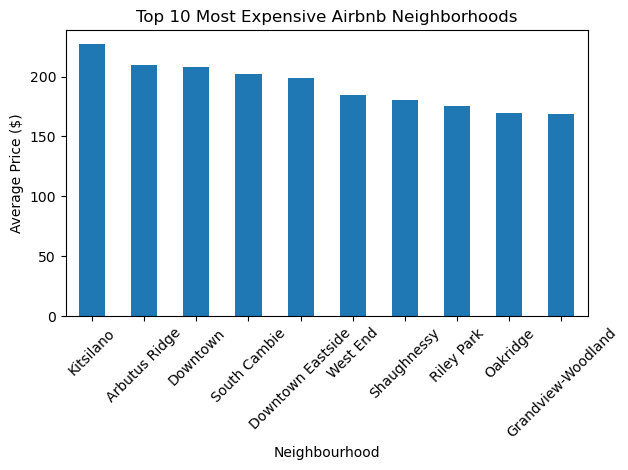

In [21]:
import matplotlib.pyplot as plt

price_by_neighbourhood.head(10).plot(kind="bar")

plt.title("Top 10 Most Expensive Airbnb Neighborhoods")
plt.ylabel("Average Price ($)")
plt.xlabel("Neighbourhood")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("images/price_by_neighbourhood.png")

plt.show()

In [22]:
room_counts = df["room_type"].value_counts()
room_counts

room_type
Entire home/apt    3646
Private room        919
Shared room          14
Name: count, dtype: int64

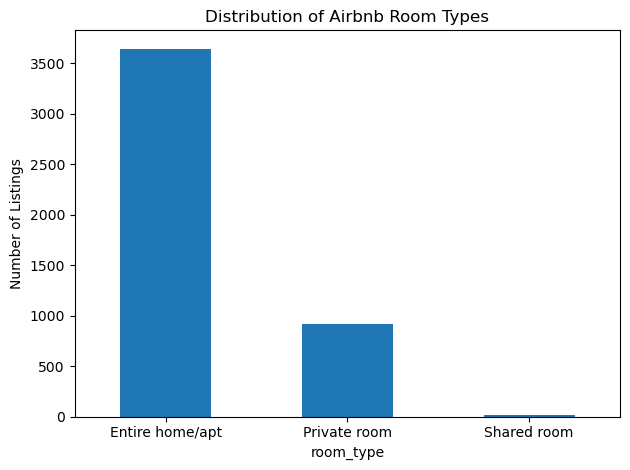

In [26]:
room_counts.plot(kind = "bar")

plt.title("Distribution of Airbnb Room Types")
plt.ylabel("Number of Listings")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("images/room_type_distribution.png")

plt.show()

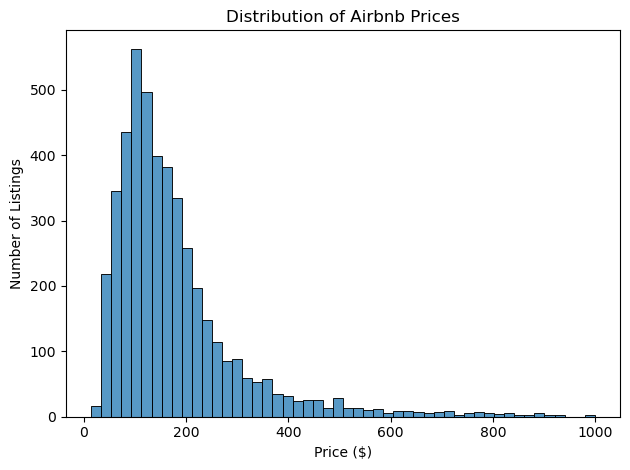

In [33]:
import seaborn as sns

sns.histplot(df["price"], bins = 50)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.tight_layout()

plt.savefig("images/price_distribution.png")

plt.show()

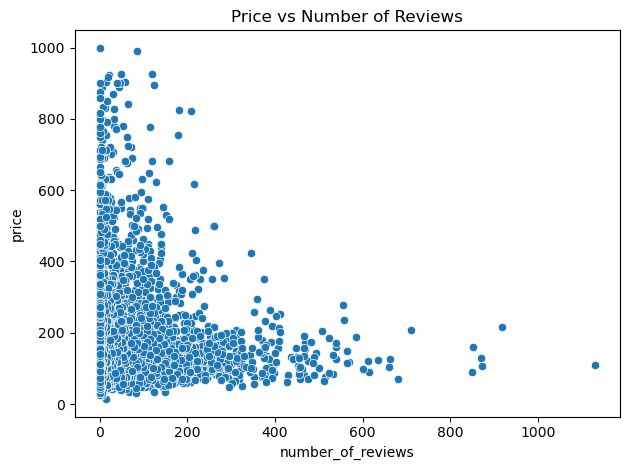

In [34]:
sns.scatterplot(x="number_of_reviews", y="price", data=df)

plt.title("Price vs Number of Reviews")

plt.tight_layout()

plt.savefig("images/reviews_vs_price.png")

plt.show()